# Notebook 9: Outlier Detection

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What are Outliers?

An outlier is a data point that is **very different from the rest of the data**. It lies unusually far from the other values.

**Analogy:** In a class where everyone is 15 to 17 years old, one student aged 45 stands out. That student is an outlier.

**Why it matters in AI/ML:** Outliers can pull the mean, inflate the standard deviation, and distort models like Linear Regression and k-Means. But sometimes the outlier is the most important point (fraud, a machine fault, a rare disease), so we must **detect first, then decide** what to do.

**Topics covered:** What are outliers, Types of outliers, IQR method, Z-score method, Box plot, Scatter plot, Treatment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

## 1. Why Do Outliers Occur?

- **Data entry or measurement error:** age = 500, or a sensor glitch
- **Natural variation:** a genuinely very rich customer, a very tall person
- **Rare real events:** fraud, system failure, a sudden spike in sales
- **Mixing different populations:** data from two different groups combined

## 2. Types of Outliers

| Type | Meaning | Example |
|---|---|---|
| **Point (Global) outlier** | A single value far from all others | One salary of 90 lakh among salaries of 20k to 50k |
| **Contextual outlier** | Normal in general, but abnormal in its context | 35°C temperature is normal in summer, but an outlier in winter |
| **Collective outlier** | A group of values that is unusual together, though each value looks normal | A flat line of zero heartbeats for 10 seconds in an ECG |

Also, by number of variables:
- **Univariate outlier:** unusual in one variable
- **Multivariate outlier:** unusual only when several variables are seen together (a person who is 150 cm tall and weighs 100 kg: both values are normal separately, but the combination is rare)

**Business Example:** A bank sees a customer who normally spends 2000 per transaction suddenly spending 2,00,000 (contextual and point outlier). This could be fraud.

**AI/ML Example:** Anomaly detection (fraud, network intrusion, machine failure) is based on finding outliers. In data cleaning, outliers are checked before training so they do not distort the model.

In [2]:
values = [12, 15, 17, 18, 20, 22, 25, 27, 30, 35, 90]
without_outlier = [v for v in values if v != 90]

print("With outlier    -> Mean:", round(np.mean(values), 2), "| Median:", np.median(values), "| Std:", round(np.std(values), 2))
print("Without outlier -> Mean:", round(np.mean(without_outlier), 2), "| Median:", np.median(without_outlier), "| Std:", round(np.std(without_outlier), 2))

With outlier    -> Mean: 28.27 | Median: 22.0 | Std: 20.57
Without outlier -> Mean: 22.1 | Median: 21.0 | Std: 6.79


**Explanation:** We calculate mean, median and standard deviation of the same data with and without the value 90.

**Interpretation:** One outlier pushes the mean up and increases the standard deviation a lot, while the median barely changes. This shows why outliers are dangerous for statistics based on the mean, and why we need methods to detect them.

## 3. IQR Method

**Definition:** The IQR method uses the middle 50% of the data. Any value that falls too far below Q1 or above Q3 is called an outlier. It does not assume any distribution, so it works well for skewed data.

**Formula:**

$$IQR = Q_3 - Q_1$$

$$Lower\ fence = Q_1 - 1.5 \times IQR \qquad Upper\ fence = Q_3 + 1.5 \times IQR$$

A value is an outlier if it is **below the lower fence or above the upper fence**. (Using 3 x IQR instead of 1.5 x IQR finds only "extreme" outliers.)

**Numerical Example:** Data = 12, 15, 17, 18, 20, 22, 25, 27, 30, 35, 90
Q1 = 17.5, Q3 = 28.5, so IQR = 11
Lower fence = 17.5 - 16.5 = 1
Upper fence = 28.5 + 16.5 = 45
The value **90 > 45, so it is an outlier**.

**Business Example:** A real estate company removes houses with unusually high or low prices (often data entry errors) before calculating the average price of an area.

**AI/ML Example:** The most common outlier check during data cleaning, especially for skewed features like income or price. `RobustScaler` also uses the IQR.

In [3]:
def detect_outliers_iqr(data, k=1.5):
    data = np.asarray(data)
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    mask = (data < lower) | (data > upper)
    return data[mask], lower, upper, iqr

outliers, lower, upper, iqr = detect_outliers_iqr(values)

print("IQR:", iqr)
print("Lower fence:", lower, "| Upper fence:", upper)
print("Outliers:", outliers)

# Using pandas on a DataFrame column
df = pd.DataFrame({"salary": values})
q1, q3 = df["salary"].quantile([0.25, 0.75])
iqr = q3 - q1
flag = (df["salary"] < q1 - 1.5 * iqr) | (df["salary"] > q3 + 1.5 * iqr)
print("\nFlagged rows:\n", df[flag])

IQR: 11.0
Lower fence: 1.0 | Upper fence: 45.0
Outliers: [90]

Flagged rows:
     salary
10      90


**Explanation:** The function finds Q1 and Q3, calculates the IQR and the two fences, and returns the values outside them. The same logic is applied to a DataFrame column using a boolean mask.

**Interpretation:** Only 90 lies outside the fences (1 to 45), so it is flagged. Notice that the fences are calculated from quartiles, which are **not affected by the outlier itself**. That is the main strength of the IQR method.

## 4. Z-Score Method

**Definition:** The Z-score tells us **how many standard deviations a value is away from the mean**. If the absolute Z-score is larger than a threshold (usually 3), the value is treated as an outlier. It works best when the data is approximately **normally distributed** (see the Empirical Rule in Notebook 4).

**Formula:**

$$Z = \frac{x - \mu}{\sigma}$$

Outlier if $|Z| > 3$ (some use 2.5 or 2 for small datasets).

**Numerical Example:** Heights have mean 170 cm and standard deviation 10 cm. A person with height 205 cm has
Z = (205 - 170) / 10 = **3.5**, which is greater than 3, so it is an outlier.
A person with 185 cm has Z = 1.5, which is normal.

**Business Example:** A factory monitors the weight of each packet. A packet whose weight is more than 3 standard deviations from the target signals a machine problem.

**AI/ML Example:** Used in data cleaning for roughly normal features, in sensor and time-series anomaly alerts, and as a simple baseline for anomaly detection.

In [4]:
def detect_outliers_zscore(data, threshold=3):
    data = np.asarray(data, dtype=float)
    z = (data - data.mean()) / data.std()
    return data[np.abs(z) > threshold], z

# Small dataset: look at the Z-scores
out_small, z_small = detect_outliers_zscore(values, threshold=2.5)
print("Z-scores:", np.round(z_small, 2))
print("Outliers (threshold 2.5):", out_small)

# Large normal dataset: threshold 3
heights = np.random.normal(170, 10, 5000)
heights = np.append(heights, [215, 120])          # add two extreme values
out_big, z_big = detect_outliers_zscore(heights, threshold=3)
print("\nTotal flagged in heights:", len(out_big))
print("Extreme values we added are flagged:", 215 in out_big, 120 in out_big)

# Using SciPy
z_scipy = stats.zscore(heights)
print("Flagged using scipy:", int(np.sum(np.abs(z_scipy) > 3)))

Z-scores: [-0.79 -0.65 -0.55 -0.5  -0.4  -0.31 -0.16 -0.06  0.08  0.33  3.  ]
Outliers (threshold 2.5): [90.]

Total flagged in heights: 17
Extreme values we added are flagged: True True
Flagged using scipy: 17


**Explanation:** We convert each value to a Z-score and flag values whose absolute Z-score is above the threshold. `stats.zscore()` does the same in one line.

**Interpretation:** In the small dataset, 90 has a Z-score of about 3.0. It is right on the border, so with threshold 3 it might be missed. The reason is that **the outlier itself inflates the mean and standard deviation**, which hides it (this is called the *masking effect*). In fact, in a sample of n = 11, no value can have a Z-score much above 3. That is why we used 2.5 here. In the large dataset (5000 values), the two extreme values are clearly detected. Also, a few normal values are flagged too, because even in a perfect normal distribution about 0.3% of values lie beyond 3 standard deviations.

**Use Z-score only for large, roughly normal data.**

Normal data        -> IQR flags 0.87% | Z-score flags 0.30%
Right-skewed data  -> IQR flags 5.19% | Z-score flags 1.84%


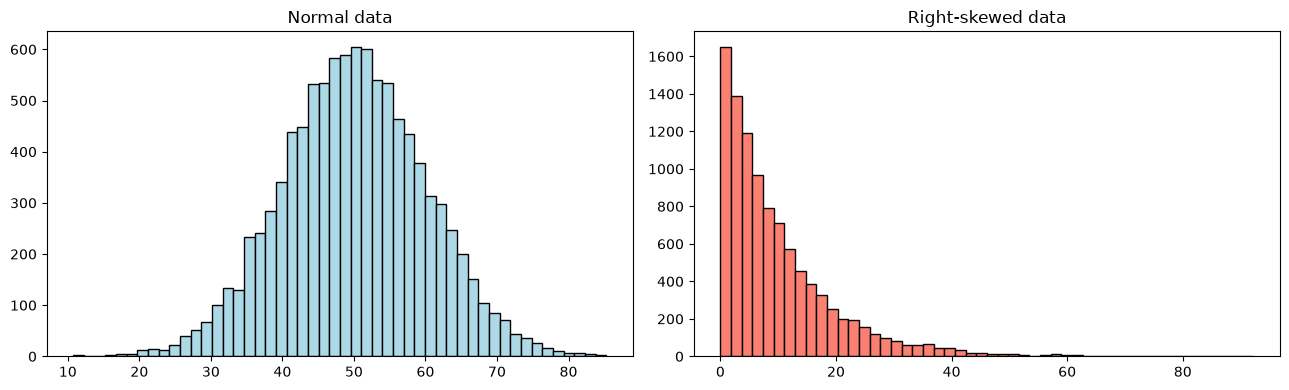

In [5]:
normal_data = np.random.normal(50, 10, 10000)
skewed_data = np.random.exponential(scale=10, size=10000)

for name, d in [("Normal data", normal_data), ("Right-skewed data", skewed_data)]:
    iqr_out, _, _, _ = detect_outliers_iqr(d)
    z_out, _ = detect_outliers_zscore(d, 3)
    print(f"{name:18s} -> IQR flags {len(iqr_out)/len(d)*100:.2f}% | Z-score flags {len(z_out)/len(d)*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(normal_data, bins=50, color="lightblue", edgecolor="black")
axes[0].set_title("Normal data")
axes[1].hist(skewed_data, bins=50, color="salmon", edgecolor="black")
axes[1].set_title("Right-skewed data")
plt.tight_layout()
plt.show()

**Explanation:** We apply both methods to normal data and to right-skewed data and compare the percentage of points flagged.

**Interpretation:** On normal data, the Z-score method flags about 0.3% and the IQR method about 0.7%. On skewed data, both methods flag mostly the **long right tail**, which is natural and not really an error. So **a flagged value is only a suspect**. We must still check whether it is an error or a real value before removing it.

| | IQR Method | Z-Score Method |
|---|---|---|
| Based on | Quartiles (middle 50%) | Mean and standard deviation |
| Assumes normal data? | No | Yes |
| Affected by outliers? | No (robust) | Yes (mean and std get inflated) |
| Best for | Skewed data, small data | Large, normal-like data |

## 5. Box Plot

**Definition:** A box plot shows the five-number summary (minimum, Q1, median, Q3, maximum) in one picture. The **box** is the IQR, the **line inside** is the median, the **whiskers** extend to the last value within 1.5 x IQR, and **dots beyond the whiskers** are outliers. It is the visual form of the IQR method.

**Business Example:** An HR team compares the salary spread of different departments in one chart and spots unusually high or low salaries.

**AI/ML Example:** Used in EDA to compare a feature across classes (for example, income of defaulters vs non-defaulters) and to quickly spot features that need outlier treatment.

C:\Users\haris\AppData\Local\Temp\ipykernel_30044\1471586442.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=salary_df, x="department", y="salary", ax=axes[1], palette="pastel")


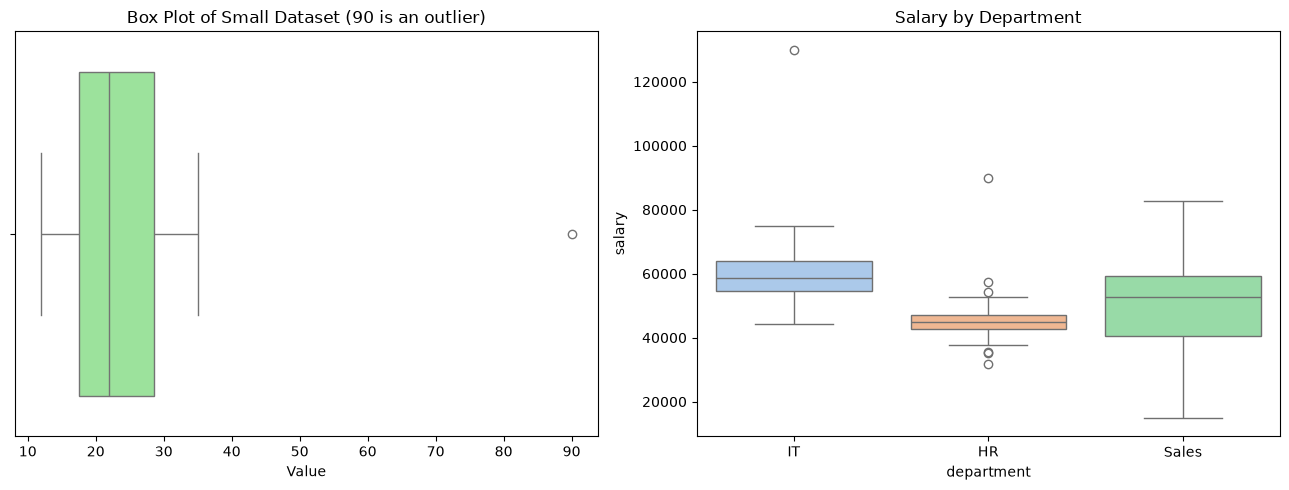

In [6]:
np.random.seed(42)
salary_df = pd.DataFrame({
    "department": ["IT"] * 60 + ["HR"] * 60 + ["Sales"] * 60,
    "salary": np.concatenate([
        np.random.normal(60000, 8000, 60),
        np.random.normal(45000, 5000, 60),
        np.random.normal(50000, 12000, 60),
    ])
})
# add a few outliers
salary_df.loc[5, "salary"] = 130000
salary_df.loc[70, "salary"] = 90000
salary_df.loc[130, "salary"] = 15000

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x=values, ax=axes[0], color="lightgreen")
axes[0].set_title("Box Plot of Small Dataset (90 is an outlier)")
axes[0].set_xlabel("Value")

sns.boxplot(data=salary_df, x="department", y="salary", ax=axes[1], palette="pastel")
axes[1].set_title("Salary by Department")

plt.tight_layout()
plt.show()

**Explanation:** The left chart is a box plot of our small dataset. The right chart compares salary across three departments, with a few extreme salaries added.

**Interpretation:** In the left plot, the dot far to the right is the value 90, which is beyond the upper whisker. In the right plot, individual dots outside the whiskers are outliers in each department (for example, one very high IT salary and one very low Sales salary). We can also compare the median and spread of the departments at a glance. **Limitation:** a box plot does not show the shape of the distribution in detail (for that we use a histogram or violin plot).

## 6. Scatter Plot

**Definition:** A scatter plot shows the relationship between **two variables** as points. It helps us find **multivariate outliers**: points that may look normal in each variable separately, but do not fit the overall pattern of the two variables together.

**Numerical Example:** If house price rises about 3 per unit of size, a house of size 9 with a very low price breaks the pattern, even though both size 9 and that low price may individually exist in the data.

**Business Example:** A bank plots income against loan amount. A customer with a low income but a very large loan stands out and may need a closer review.

**AI/ML Example:** In regression, such points have a strong influence on the fitted line. Scatter plots of the features vs target are used to find these influential points before training.

Regression line WITHOUT outliers: y = 2.95x + 5.24
Regression line WITH outliers   : y = 2.46x + 8.61
Correlation without outliers: 0.973
Correlation with outliers   : 0.65


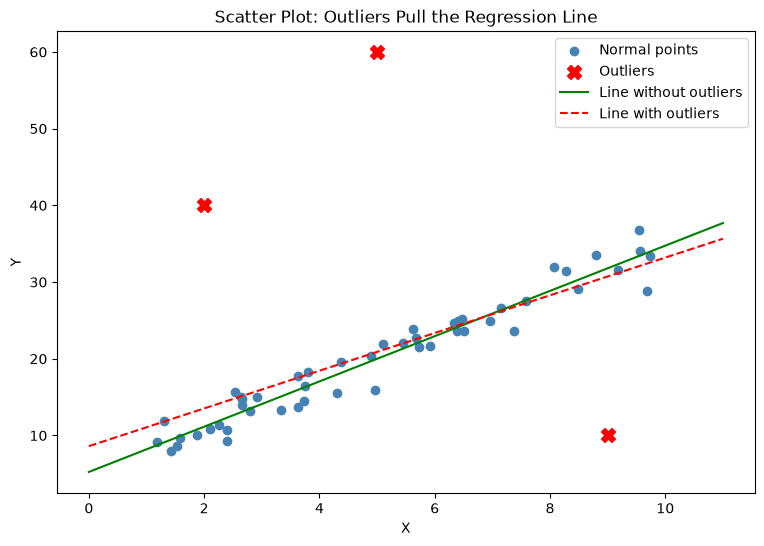

In [7]:
np.random.seed(42)
x = np.random.uniform(1, 10, 50)
y = 3 * x + 5 + np.random.normal(0, 2, 50)

# Add three outliers
x_out = np.append(x, [2, 9, 5])
y_out = np.append(y, [40, 10, 60])

slope_clean, intercept_clean = np.polyfit(x, y, 1)
slope_out, intercept_out = np.polyfit(x_out, y_out, 1)

print("Regression line WITHOUT outliers: y = {:.2f}x + {:.2f}".format(slope_clean, intercept_clean))
print("Regression line WITH outliers   : y = {:.2f}x + {:.2f}".format(slope_out, intercept_out))
print("Correlation without outliers:", round(np.corrcoef(x, y)[0, 1], 3))
print("Correlation with outliers   :", round(np.corrcoef(x_out, y_out)[0, 1], 3))

xs = np.linspace(0, 11, 100)
plt.figure(figsize=(9, 6))
plt.scatter(x, y, color="steelblue", label="Normal points")
plt.scatter([2, 9, 5], [40, 10, 60], color="red", s=100, marker="X", label="Outliers")
plt.plot(xs, slope_clean * xs + intercept_clean, "g-", label="Line without outliers")
plt.plot(xs, slope_out * xs + intercept_out, "r--", label="Line with outliers")
plt.title("Scatter Plot: Outliers Pull the Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

**Explanation:** We create data with a clear straight-line pattern, then add three points that break it. We fit a line with and without the outliers using `np.polyfit`, and compare slope and correlation.

**Interpretation:** The green line follows the real pattern (slope close to 3). The red dashed line is pulled toward the outliers, so the slope changes and the correlation becomes weaker. The point at (9, 10) has an ordinary x and an ordinary y, so a single-variable check would miss it, but the scatter plot shows it clearly as a multivariate outlier. **Outliers can make a regression model learn the wrong relationship.**

## 7. What to Do After Detecting Outliers?

| Option | How | Use when |
|---|---|---|
| **Remove** | Delete the rows | Clear errors (age = 500), and we have plenty of data |
| **Cap (Winsorize)** | Replace values beyond the fences with the fence value | We want to keep the row but limit the influence |
| **Transform** | Log or square root | Right-skewed data |
| **Use robust methods** | Median, IQR, RobustScaler, tree-based models | Outliers are real and must stay |
| **Keep and study separately** | Analyze them on their own | Fraud, fault or anomaly detection (the outlier is the target) |

**Rule:** Never remove an outlier blindly. First ask whether it is an error or a real value.

In [10]:
import numpy as np
import pandas as pd
from scipy import stats

# Cell 4-la irundha data, inga thirumba define pannirukken
values = [12, 15, 17, 18, 20, 22, 25, 27, 30, 35, 90]

data = np.array(values, dtype=float)
q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

# 1. Remove
removed = data[(data >= lower) & (data <= upper)]

# 2. Cap (winsorize)
capped = np.clip(data, lower, upper)

# 3. Log transform
logged = np.log(data)

print("Original :", data)
print("Removed  :", removed)
print("Capped   :", capped)
print("Log      :", np.round(logged, 2))

summary = pd.DataFrame({
    "Method": ["Original", "Removed", "Capped", "Log transform"],
    "Mean": [data.mean(), removed.mean(), capped.mean(), logged.mean()],
    "Std": [data.std(), removed.std(), capped.std(), logged.std()],
    "Skewness": [stats.skew(data), stats.skew(removed), stats.skew(capped), stats.skew(logged)],
}).round(2)
print("\n", summary)

Original : [12. 15. 17. 18. 20. 22. 25. 27. 30. 35. 90.]
Removed  : [12. 15. 17. 18. 20. 22. 25. 27. 30. 35.]
Capped   : [12. 15. 17. 18. 20. 22. 25. 27. 30. 35. 45.]
Log      : [2.48 2.71 2.83 2.89 3.   3.09 3.22 3.3  3.4  3.56 4.5 ]

           Method   Mean    Std  Skewness
0       Original  28.27  20.57      2.36
1        Removed  22.10   6.79      0.38
2         Capped  24.18   9.23      0.84
3  Log transform   3.18   0.51      1.25


**Explanation:** We apply three treatments to the same data: removing the outlier, capping it at the upper fence (45), and applying a log transform. Then we compare mean, standard deviation and skewness.

**Interpretation:** Removing and capping both reduce the mean and standard deviation a lot, and the skewness drops. Capping keeps all 11 rows, so no data is lost. The log transform keeps all values and reduces the effect of the large value by compressing the scale. The choice depends on whether the outlier is an error or a genuine value.

## Summary: Which Method to Use?

| Method | Type | Best used when | Main limitation |
|---|---|---|---|
| IQR method | Numeric, one variable | Skewed data, any distribution | Flags natural tail values in skewed data |
| Z-score method | Numeric, one variable | Large, roughly normal data | Mean and std are affected by outliers (masking) |
| Box plot | Visual, one variable | Quick check, comparing groups | Does not show distribution shape |
| Scatter plot | Visual, two variables | Finding multivariate outliers | Hard with many variables |

For many variables, advanced methods are used: **Isolation Forest, Local Outlier Factor (LOF), DBSCAN, Mahalanobis distance**.

## Advantages
- Cleaner data gives more reliable statistics and better models
- IQR and box plots are simple, fast and need no distribution assumption
- Detection can reveal data errors or important rare events (fraud, faults)
- Visual methods make outliers easy to explain to non-technical people

## Limitations
- Statistical rules only find *unusual* values, they cannot tell if the value is an error or real
- Z-score depends on the mean and std, so it is affected by the outliers it tries to find
- IQR and Z-score look at one variable at a time and can miss multivariate outliers
- Removing real outliers loses important information and can bias the model
- The thresholds (1.5 x IQR, Z = 3) are conventions, not laws